# Bias Analysis - Study3

## Loading Libraries & Data

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import geopandas as gpd
import matplotlib.colors as mcolors
import requests
from pathlib import Path
import json
import re
import yfinance as yf
import math
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy import stats
import itertools
import string

In [2]:
ageRisk = pd.read_csv('./data/ageRisk_long.csv', index_col=0)

In [3]:
ageRisk.shape

(962, 12)

## Resolving ETFs 

In [4]:
def get_position_weight(portfolio_df):
    position_weight = portfolio_df / portfolio_df.sum()
    return position_weight

ageRisk_select_cols = ['ai', 'age', 'risk-taking', 'cond', 'iteration', 'ticker_symbol', 'amount_to_invest', 'weight', 'sector', 'asset_type', 'country']
ageRisk['weight'] = ageRisk.groupby(['ai', 'age', 'risk-taking', 'cond', 'iteration'])['amount_to_invest'].transform(get_position_weight)
ageRisk = ageRisk[ageRisk_select_cols]

ageRisk_unique_etfs = ageRisk[ageRisk["asset_type"] == "ETF"]["ticker_symbol"].unique()
etfs = ageRisk_unique_etfs

ageRisk_unique_funds = ageRisk[ageRisk["asset_type"] == "MUTUALFUND"]["ticker_symbol"].unique()
funds = ageRisk_unique_funds

In [5]:
ageRisk_unique_equities = ageRisk[ageRisk["asset_type"] == "EQUITY"]["ticker_symbol"].unique()
equities = ageRisk_unique_equities

In [6]:
def prepare_refinitiv_dataset(df, columns):
    df = df.iloc[1:].reset_index()
    df.columns = columns
    df['economic_sector'] = df['economic_sector'].replace('Unable to resolve all requested identifiers.', np.nan)
    condition = df['country'].str.startswith('Unable to')
    df.loc[condition & ~df['country'].isna(), 'country'] = np.nan
    condition = df['economic_sector'].str.startswith('Unable to')
    df.loc[condition & ~df['economic_sector'].isna(), 'country'] = np.nan
    df['weight'] = pd.to_numeric(df['weight'], errors='coerce')
    df['weight'] = df['weight'].fillna(100.0)
    df['weight'] = df['weight'] / 100
    df['fund'] = df['fund'].str.split('.').str[0]
    return df

study1_etf_data = pd.read_csv('../study1/etf_holdings/refinitiv/etfs_refinitiv.csv', index_col=0, low_memory=False)
study1_fund_data = pd.read_csv('../study1/mutualFund_holdings/refinitiv/mutualFunds_refinitiv.csv', index_col=0, low_memory=False)

cols_refinitiv = ['fund', 'code', 'equity', 'symbol', '#shares', 'weight', 'country', 'type', 'economic_sector']
study1_etf_data = prepare_refinitiv_dataset(study1_etf_data, cols_refinitiv)
study1_etfs = study1_etf_data['fund'].unique()

study1_fund_data = study1_fund_data.iloc[:,:-2]
study1_fund_data = prepare_refinitiv_dataset(study1_fund_data, cols_refinitiv)
study1_funds = study1_fund_data['fund'].unique()

study2b_fund_data = pd.read_csv('../study2b/data/refinitiv/funds_refinitiv_study2b.csv', index_col=0, low_memory=False)
study2b_fund_data = prepare_refinitiv_dataset(study2b_fund_data, cols_refinitiv)
study2b_funds = study2b_fund_data['fund'].unique()

study2a_addition_data = pd.read_csv('../study1/etf_holdings/refinitiv/additions_refinitiv.csv', index_col=0)
study2a_addition_data = prepare_refinitiv_dataset(study2a_addition_data, cols_refinitiv)
study2a_additions = study2a_addition_data['fund'].unique()

prev_etfs = np.union1d(np.union1d(study1_etfs, study2b_funds), study2a_additions ) 
prev_funds = np.union1d(np.union1d(study1_funds, study2b_funds), study2a_additions)

new_etfs = [item for item in etfs if item not in prev_etfs]
new_funds = [item for item in funds if item not in prev_funds]

cols_refinitiv = ['fund', 'code', 'equity', 'symbol', '#shares', 'weight', 'country', 'economic_sector']
study2a_fund_data = pd.read_csv('../study2a/data/refinitiv/funds_refinitiv_study2a.csv', index_col=0, low_memory=False)
study2a_fund_data = prepare_refinitiv_dataset(study2a_fund_data, cols_refinitiv)
study2a_fund_data = study2a_fund_data[study2a_fund_data['fund'].isin(new_funds)]

study2a_etf_data = pd.read_csv('../study2a/data/refinitiv/etfs_refinitiv_study2a.csv', index_col=0)
study2a_etf_data = prepare_refinitiv_dataset(study2a_etf_data, cols_refinitiv)
study2a_etf_data = study2a_etf_data[study2a_etf_data['fund'].isin(new_etfs)]

prev_etf_data = pd.concat([
    study1_etf_data, 
    study2b_fund_data,
    study2a_addition_data,
    study2a_etf_data], ignore_index=True)

prev_fund_data = pd.concat([
    study1_etf_data, 
    study1_fund_data, 
    study2a_addition_data, 
    study2b_fund_data,
    study2a_etf_data,
    study2a_fund_data], ignore_index=True)

prev_etfs = prev_etf_data['fund'].unique()
prev_funds = prev_fund_data['fund'].unique()

new_etfs = [item for item in etfs if item not in prev_etfs]
new_funds = [item for item in funds if item not in prev_funds]

In [7]:
new_etfs

['ESGV',
 'EAGG',
 'DSI',
 'WOMN',
 'BGRN',
 'GRNB',
 'ESGD',
 'ACWI',
 'CRBN',
 'KRMA',
 'EFIV',
 'SUSL',
 'VCEB',
 'SUSA',
 'MOO',
 'VGIT',
 'ESGU',
 'SDG',
 'ESGW',
 'PHO',
 'BIV',
 'DBA',
 'EWZ',
 'JNK',
 'BKLN',
 'SUSC',
 'VSGX',
 'ESGE',
 'SPYX']

In [8]:
resStr_etf = ""
os = ['BGRN', 'ESGD', 'ACWI', 'KRMA', 'SUSL', 'VGIT', 'ESGU', 'SDG', 'PHO', 'SUSC', 'ESGE']
ks = ['ESGV', 'EAGG', 'WOMN', 'GRNB', 'CRBN', 'EFIV', 'VCEB', 'SUSA', 'BKLN', 'VSGX', 'SPYX']
s = ['ESGW']
for etf in new_etfs:
    if etf in os:
        resStr_etf += f'{etf}.O;'
    elif etf in ks:
        resStr_etf += f'{etf}.K;'
    elif etf in s:
        resStr_etf += f'{etf}.S;'
    else:
        resStr_etf += f'{etf};'
resStr_etf

'ESGV.K;EAGG.K;DSI;WOMN.K;BGRN.O;GRNB.K;ESGD.O;ACWI.O;CRBN.K;KRMA.O;EFIV.K;SUSL.O;VCEB.K;SUSA.K;MOO;VGIT.O;ESGU.O;SDG.O;ESGW.S;PHO.O;BIV;DBA;EWZ;JNK;BKLN.K;SUSC.O;VSGX.K;ESGE.O;SPYX.K;'

In [9]:
new_funds

[nan,
 'TISCX',
 'CGAFX',
 'TICRX',
 'TICSX',
 'VFTAX',
 'CSIIX',
 'CSIEX',
 'PRILX',
 'CFGRX',
 'DSEFX',
 'TICCX',
 'PAXIX',
 'CIBFX',
 'CCPIX',
 'TSBRX',
 'TSBIX',
 'PRFDX',
 'CGAEX',
 'IEMGX',
 'PRFIX',
 'CGRIX',
 'CAAFX',
 'TRIIX',
 'PXWEX']

In [10]:
resStr_mutualFunds = "";
for fund in new_funds:
        resStr_mutualFunds += f'{fund}.O;'
resStr_mutualFunds

'nan.O;TISCX.O;CGAFX.O;TICRX.O;TICSX.O;VFTAX.O;CSIIX.O;CSIEX.O;PRILX.O;CFGRX.O;DSEFX.O;TICCX.O;PAXIX.O;CIBFX.O;CCPIX.O;TSBRX.O;TSBIX.O;PRFDX.O;CGAEX.O;IEMGX.O;PRFIX.O;CGRIX.O;CAAFX.O;TRIIX.O;PXWEX.O;'

In [11]:
resStr_funds = resStr_etf + resStr_mutualFunds
resStr_funds

'ESGV.K;EAGG.K;DSI;WOMN.K;BGRN.O;GRNB.K;ESGD.O;ACWI.O;CRBN.K;KRMA.O;EFIV.K;SUSL.O;VCEB.K;SUSA.K;MOO;VGIT.O;ESGU.O;SDG.O;ESGW.S;PHO.O;BIV;DBA;EWZ;JNK;BKLN.K;SUSC.O;VSGX.K;ESGE.O;SPYX.K;nan.O;TISCX.O;CGAFX.O;TICRX.O;TICSX.O;VFTAX.O;CSIIX.O;CSIEX.O;PRILX.O;CFGRX.O;DSEFX.O;TICCX.O;PAXIX.O;CIBFX.O;CCPIX.O;TSBRX.O;TSBIX.O;PRFDX.O;CGAEX.O;IEMGX.O;PRFIX.O;CGRIX.O;CAAFX.O;TRIIX.O;PXWEX.O;'

### Prepare ESG strings

In [12]:
resStr_equities = ""
os = ['AAPL', 'MSFT', 'TSLA', 'META', 'AMZN', 'GOOGL', 'NVDA', 'BYND', 'MRNA', 'DKNG', 'FSLR', 
      'ADBE', 'TTD', 'AMD', 'CSX', 'ETSY']
ks = ['PLTR', 'TDOC', 'HASI',]
pk = ['VWDRY']
for equity in equities:
    if equity in os:
        resStr_equities += f'{equity}.O;'
    elif equity in ks:
        resStr_equities += f'{equity}.K;'
    elif equity in pk:
        resStr_equities += f'{equity}.PK;'
    else:
        resStr_equities += f'{equity};'
resStr_equities

'JNJ;AAPL.O;MSFT.O;KO;PG;TSLA.O;META.O;SQ;AMZN.O;GOOGL.O;NVDA.O;GME;BYND.O;PLTR.K;MRNA.O;NIO;DKNG.O;AMC;NEE;WM;MMM;FSLR.O;VWDRY.PK;ADBE.O;NKE;AWK;BAC;TDOC.K;CRM;BEP;T;LC;TTD.O;PFE;AMD.O;HASI.K;DLR;CSX.O;UL;ETSY.O;BXP;ARE;AMT;BG;XYL;NTR;'

In [13]:
resStr_etf_all = ""
os = ['BGRN', 'ESGD', 'ACWI', 'KRMA', 'SUSL', 'VGIT', 'ESGU', 'SDG', 'PHO', 'SUSC', 'ESGE',
     'MCHI', 'IXUS', 'ACWX', 'DVY', 'CIBR',
      'ACWX', 'DVY', 'VCLT', 'IXUS', 'IGOV',
      'QQQ', 'SHY', 'VXUS', 'ICLN', 'BND', 'BOTZ', 'IEF', 'TLT', 'SOXX', 'ANGL', 'VCSH', 'REIT']
ks = ['ESGV', 'EAGG', 'WOMN', 'GRNB', 'CRBN', 'EFIV', 'VCEB', 'SUSA', 'BKLN', 'VSGX', 'SPYX',
     'SCHK', 'REET', 'INDA', 'ARKF', 'SCHD', 'USMV', 'SCHA', 'IA', 'IAGG', 'GOVT', 'IEFA', 'ARKK', 
      'ARKW', 'ARKG', 'NOBL', 'IEMG', 'SCHH']
s = ['ESGW']
for etf in etfs:
    if etf in os:
        resStr_etf_all += f'{etf}.O;'
    elif etf in ks:
        resStr_etf_all += f'{etf}.K;'
    elif etf in s:
        resStr_etf_all += f'{etf}.S;'
    else:
        resStr_etf_all += f'{etf};'
resStr_etf_all

'VOO;GOVT.K;VNQ;BND.O;VIG;AGG;IEF.O;IAU;DBC;QQQ.O;VTI;SPY;ICLN.O;ARKK.K;VWO;VGT;XLV;ARKG.K;ESGV.K;EAGG.K;DSI;WOMN.K;BGRN.O;GRNB.K;ESGD.O;ACWI.O;CRBN.K;KRMA.O;EFIV.K;SUSL.O;VCEB.K;SUSA.K;MOO;FAN;VGIT.O;NOBL.K;LQD;VT;MUB;EEM;ESGU.O;SDG.O;TAN;ESGW.S;PHO.O;EFA;BIV;DVY.O;GLD;XLK;VYM;HYG;VB;USO;DBA;MCHI.O;EWZ;JNK;BKLN.K;BOTZ.O;TLT.O;SUSC.O;VSGX.K;ESGE.O;PBW;SPYX.K;'

In [14]:
resStr_mutualFunds_all = "";
delisted = ['VTWSX', 'VDAIX']
for fund in funds:
    if fund in delisted:
        resStr_mutualFunds_all += f'{fund}.O^K19;'
    else:
        resStr_mutualFunds_all += f'{fund}.O;'
resStr_mutualFunds_all

'VFINX.O;VTSAX.O;VSMGX.O;nan.O;FCNTX.O;TISCX.O;CGAFX.O;TICRX.O;TICSX.O;VFTAX.O;PRBLX.O;CSIIX.O;CSIEX.O;PRILX.O;CFGRX.O;DSEFX.O;VFIAX.O;SWPPX.O;VTSMX.O;VBTLX.O;TICCX.O;PAXIX.O;CIBFX.O;CCPIX.O;TSBRX.O;TSBIX.O;PRFDX.O;CGAEX.O;IEMGX.O;PRFIX.O;CGRIX.O;CAAFX.O;TRIIX.O;PXWEX.O;'

In [15]:
esg_str = resStr_equities + resStr_etf_all + resStr_mutualFunds_all
esg_str

'JNJ;AAPL.O;MSFT.O;KO;PG;TSLA.O;META.O;SQ;AMZN.O;GOOGL.O;NVDA.O;GME;BYND.O;PLTR.K;MRNA.O;NIO;DKNG.O;AMC;NEE;WM;MMM;FSLR.O;VWDRY.PK;ADBE.O;NKE;AWK;BAC;TDOC.K;CRM;BEP;T;LC;TTD.O;PFE;AMD.O;HASI.K;DLR;CSX.O;UL;ETSY.O;BXP;ARE;AMT;BG;XYL;NTR;VOO;GOVT.K;VNQ;BND.O;VIG;AGG;IEF.O;IAU;DBC;QQQ.O;VTI;SPY;ICLN.O;ARKK.K;VWO;VGT;XLV;ARKG.K;ESGV.K;EAGG.K;DSI;WOMN.K;BGRN.O;GRNB.K;ESGD.O;ACWI.O;CRBN.K;KRMA.O;EFIV.K;SUSL.O;VCEB.K;SUSA.K;MOO;FAN;VGIT.O;NOBL.K;LQD;VT;MUB;EEM;ESGU.O;SDG.O;TAN;ESGW.S;PHO.O;EFA;BIV;DVY.O;GLD;XLK;VYM;HYG;VB;USO;DBA;MCHI.O;EWZ;JNK;BKLN.K;BOTZ.O;TLT.O;SUSC.O;VSGX.K;ESGE.O;PBW;SPYX.K;VFINX.O;VTSAX.O;VSMGX.O;nan.O;FCNTX.O;TISCX.O;CGAFX.O;TICRX.O;TICSX.O;VFTAX.O;PRBLX.O;CSIIX.O;CSIEX.O;PRILX.O;CFGRX.O;DSEFX.O;VFIAX.O;SWPPX.O;VTSMX.O;VBTLX.O;TICCX.O;PAXIX.O;CIBFX.O;CCPIX.O;TSBRX.O;TSBIX.O;PRFDX.O;CGAEX.O;IEMGX.O;PRFIX.O;CGRIX.O;CAAFX.O;TRIIX.O;PXWEX.O;'

In [16]:
# BSCM ended on 15.12.2022, GLD, SLV, DbC

## Loading Data from Refinitiv & Resolving Dataset

In [17]:
cols_refinitiv = ['fund', 'code', 'equity', 'symbol', '#shares', 'weight', 'country', 'economic_sector', 'industry_group']

study3_refinitiv_data = pd.read_csv('./data/refinitiv/refinitiv_study3.csv', index_col=0, low_memory=False)
study3_refinitiv_data = prepare_refinitiv_dataset(study3_refinitiv_data, cols_refinitiv)
study3_refinitiv_data = study3_refinitiv_data[study3_refinitiv_data['fund'].isin(new_funds)]
study3_refinitiv_data = study3_refinitiv_data.drop('industry_group', axis=1)

etf_data = pd.concat([prev_etf_data, study3_refinitiv_data], ignore_index=True)

fund_data = pd.concat([prev_fund_data, study3_refinitiv_data], ignore_index=True)

In [18]:
def create_ticker(row):
    if row['asset_type'] in ['ETF', 'MUTUALFUND']:
        return row['symbol']
    else:
        return row['ticker_symbol']

def create_ticker_l2(row):
    if row['asset_type'] in ['ETF', 'MUTUALFUND']:
        return row['ticker'] if pd.isnull(row['equity_l2']) else row['symbol_l2']
    else:
        return row['ticker']
    
def harmonize_sectors(sector):
    if sector == 'Consumer Cyclicals':
        return 'Consumer Cyclical'
    elif sector == 'Financial Services':
        return 'Financials'
    elif sector == 'Consumer Defensive':
        return 'Consumer Non-Cyclicals'
    else:
        return sector
    
def resolve_layer2(df, select_cols):
    df = df.merge(etf_data, left_on='ticker', right_on='fund', how='left', suffixes=('_l1','_l2'))
    df['weight_l2'].fillna(1, inplace=True)
    df['weight'] = df['weight_l1'] * df['weight_l2']
    df['sector'] = df['sector'].fillna(df['economic_sector_l2'])
    df['country'] = df.apply(
        lambda row: row['country_l2'] if pd.isnull(row['country_l1']) else row['country_l1'],
        axis=1
    )
    df['ticker'] = df.apply(lambda row: create_ticker_l2(row), axis=1)
    df['amount'] = df.apply(lambda row: row['amount'] * row['weight_l2'], axis=1)

    condition = df['country'].str.startswith('Unable to')
    df.loc[condition & ~df['country'].isna(), 'country'] = np.nan
    condition = df['sector'].str.startswith('Unable to')
    df.loc[condition & ~df['sector'].isna(), 'sector'] = np.nan

    df['sector'] = df['sector'].fillna('UNKNOWN')
    df['sector'] = df['sector'].apply(harmonize_sectors)
    df['country'] = df['country'].fillna('UNKNOWN')
    df['ticker'] = df['ticker'].fillna('UNKNOWN')
    #df = df[select_cols]
    return df

def prepare_data(df, select_cols):
    df = df.merge(fund_data, left_on='ticker_symbol', right_on='fund', how='left')
    df['weight_y'].fillna(1, inplace=True)
    df['weight'] = df['weight_x'] * df['weight_y']
    df['sector'] = df['sector'].fillna(df['economic_sector'])
    df['sector'] = df.apply(
        lambda row: 'Crypto' if row['asset_type'] == 'CRYPTOCURRENCY' else row['sector'],
        axis=1
    )
    df['country_x'] = df['country_x'].str.upper()
    df['country'] = df.apply(
        lambda row: row['country_y'] if pd.isnull(row['country_x']) else row['country_x'],
        axis=1
    )
    df['ticker'] = df.apply(lambda row: create_ticker(row), axis=1)
    df['amount'] = df.apply(lambda row: row['amount_to_invest'] * row['weight_y'], axis=1)
    df['sector'] = df['sector'].apply(harmonize_sectors)
    #return df
    return resolve_layer2(df, select_cols)

def prepare_benchmark(df):
    df = df.rename(columns={'economic_sector': 'sector'})
    df['amount'] = df['weight'].apply(lambda x: x * 10000)
    df['sector'] = df['sector'].fillna('UNKNOWN')
    df['country'] = df['country'].fillna('UNKNOWN')
    df['sector'] = df['sector'].apply(harmonize_sectors)
    return df

ageRisk_select_cols = ['ai', 'age', 'risk-taking', 'cond', 'iteration', 'asset_type', 'ticker', 'weight', 'country', 'sector', 'amount']
ageRisk_resolved = prepare_data(ageRisk, ageRisk_select_cols)

benchmark_cols_refinitiv = ['fund', 'equity', 'symbol', '#shares', 'weight', 'country', 'economic_sector', 'business_sector', 'industry_group']
benchmark = pd.read_csv('../study1/benchmark/refinitiv/benchmarks_refinitiv.csv', index_col=0)
benchmark_prepared = prepare_benchmark(prepare_refinitiv_dataset(benchmark, benchmark_cols_refinitiv))


In [19]:
ageRisk_resolved.head()

,ai,age,risk-taking,cond,iteration,ticker_symbol,amount_to_invest,weight_x,sector,asset_type,...,code_l2,equity_l2,symbol_l2,#shares_l2,weight_l2,country_l2,type_l2,economic_sector_l2,weight,country
0,ChatGPT,15,averse,control,0,VOO,3000.0,0.3,Technology,ETF,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.022664,UNITED STATES
1,ChatGPT,15,averse,control,0,VOO,3000.0,0.3,Technology,ETF,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.019490,UNITED STATES
2,ChatGPT,15,averse,control,0,VOO,3000.0,0.3,Consumer Cyclical,ETF,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.009311,UNITED STATES
3,ChatGPT,15,averse,control,0,VOO,3000.0,0.3,Technology,ETF,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.009018,UNITED STATES
4,ChatGPT,15,averse,control,0,VOO,3000.0,0.3,Technology,ETF,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.006152,UNITED STATES


In [20]:
benchmark_ftse = benchmark_prepared[benchmark_prepared['fund'] == 'VFAWF']
benchmark_msci = benchmark_prepared[benchmark_prepared['fund'] == 'IUSQ']
benchmark_vt = pd.read_csv('../study1/benchmark/refinitiv/benchmark_vt.csv', index_col=0)

In [21]:
def prepare_dataframe(df, col_name, sep_col = None, sep_col_values = None):
    ages = [15, 30, 50]
    risk_taking = ['averse', 'neutral', 'seeking']
    cond = df['cond'].unique()
    iterations = list(range(10))  # 0 to 9
    
    if sep_col:
        combinations = list(itertools.product(ages, risk_taking, cond, iterations, sep_col_values))

        missing_rows = pd.DataFrame(combinations, columns=['age', 'risk-taking', 'cond', 'iteration', sep_col])
        missing_rows[col_name] = 0

        result_df = df.merge(missing_rows, on=['age', 'risk-taking', 'iteration', 'cond', sep_col], how='outer', suffixes=('', '_missing'))
        result_df[col_name].fillna(0, inplace=True)
        return result_df
    else:
        combinations = list(itertools.product(ages, risk_taking, cond, iterations))
        
        missing_rows = pd.DataFrame(combinations, columns=['age', 'risk-taking', 'cond', 'iteration'])
        missing_rows[col_name] = 0

        result_df = df.merge(missing_rows, on=['age', 'risk-taking', 'cond', 'iteration'], how='outer', suffixes=('', '_missing'))
        result_df[col_name].fillna(0, inplace=True)
        return result_df

## Graphs

In [22]:
mpl.rcParams['font.size'] = 14  # Change the size to your preference
mpl.rcParams['font.sans-serif'] = 'Arial'

In [23]:
def fill_options(filtered_df, res_df, elem, group_cols):
    elems = filtered_df[elem].unique()
    group_cols_df = filtered_df[group_cols].drop_duplicates()
    all_combinations = pd.DataFrame([row + [el] for row in group_cols_df.values.tolist() for el in elems], columns=group_cols+[elem])
    merged = pd.merge(all_combinations, res_df, on=group_cols+[elem], how='left')
    merged.fillna(0, inplace=True)
    return merged

def calculate_weight(group, elem):
    summed = group.groupby(elem)['amount'].sum().reset_index()
    total_amount = summed['amount'].sum()
    summed['weight'] = summed['amount'] / total_amount
    return summed

def create_benchmark_dummy(df, benchmark_label):
    benchmark_ai = f'{benchmark_label}'
    df['cond'] = benchmark_ai
    df['ai'] = benchmark_ai
    df['age'] = 1
    df['risk-taking'] = 'low'
    df['iteration'] = 0
    return df

def show_anova(df, column, group1, group2=None):
    if group1 and group2:
        df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)
    else:
        df = df.copy()
        df.loc[:, 'label'] = df.loc[:, group1]
    
    model = ols(f'{column} ~ label', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    tukey_results = pairwise_tukeyhsd(endog=df[column], groups=df['label'], alpha=0.05)
    print(tukey_results)
    
def show_ttest(raw, column, groups, benchmark):
    for group_name, group_data in raw.groupby(groups):
        group_values = group_data[column]
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark)
        print(f'group: {group_name} got t: {t_statistic} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark, 4)}')

def calc_stats(raw, column, benchmark, group1, group2=None):
    show_anova(raw, column, group1, group2)
    groups = [group1, group2] if group2 != None else [group1]
    show_ttest(raw, column, groups, benchmark)
    
    grouped = raw.groupby(groups)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    return means, std_devs, sample_sizes, standard_errors

def print_stats(raw, column, benchmark, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = calc_stats(raw, column, benchmark, group1)
    
    print(f'means:\n{round(means, 4)}')
    print(f'stds:\n{round(std_devs,4)}')
    print(sample_sizes)
    return means, std_devs, sample_sizes, standard_errors
    

def show_benchmark_violinplot(raw, benchmark, benchmark_label, column, column_label, group1, filename):
    means, _, _,_ = print_stats(raw, column, benchmark, group1)
    
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.violinplot(data=raw, x=group1, y=column, split=False, inner=None, linewidth=1, ax=ax, edgecolor='black', fill=None, zorder=2)

    # Add boxplots
    sns.boxplot(data=raw, x=group1, y=column, hue=group1, width=0.2, palette="Set3", ax=ax, 
                boxprops=dict(edgecolor='black', facecolor=(1, 1, 1, 0)), 
                medianprops=dict(linewidth=2, color='black'), 
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'), fliersize=0, legend=False, zorder=4)

    for i, group in enumerate(raw[group1].unique()):
        group_data = raw[raw[group1] == group][column]
        jitter = np.random.normal(i, 0.04, size=len(group_data))
        ax.scatter(jitter, group_data, s=100, alpha=0.4, zorder=3)  # Set zorder to ensure dots are on top

        # Calculate the mean and add it to the boxplot
        mean = group_data.mean()
        ax.scatter(i, mean, color='black', s=50, label='mean', zorder=5)

    ax.axhline(y=benchmark, color='black', linestyle='--', label=benchmark_label, zorder=4)
    ax.set_ylabel(column_label)
    ax.set_xticks(range(len(means.index)))
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    ax.set_xlabel('Condition')
    ax.grid(True, zorder=1)
    ax.text(1.02, benchmark, benchmark_label, va='center', ha="left", bbox=dict(facecolor='none', edgecolor='none', boxstyle='round,pad=0.2'), transform=ax.get_yaxis_transform())

    plt.subplots_adjust(hspace=1)
    plt.tight_layout()
    if filename is not None:
        plt.savefig(f'./figures/{filename}.png')
    plt.show()

def print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label):
    # Create a stacked barplot with error bars
    ax = means.plot(kind='bar', stacked=False, yerr=standard_errors.values.T, capsize=5, figsize=(4, 5), zorder=2, color=['darkgrey'])
    ax.axhline(y=benchmark, color='red', linestyle='--', label=benchmark_label)
    ax.set_ylabel(column_label)
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    ax.set_xlabel('Condition')
    ax.grid(True, zorder=1)
    ax.annotate(benchmark_label, xy=(0, benchmark), xytext=(0, 1),
            color='red', fontsize=10, ha='left', va='bottom', textcoords='offset points')

    # Show the plot
    plt.subplots_adjust(hspace=1)
    plt.tight_layout()
    plt.show()
    

def show_benchmark_errplot(raw, benchmark, benchmark_label, column, column_label, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = calc_stats(raw, column, benchmark, group1, group2)
    print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label)

def show_benchmark_errplot_complete(raw, benchmark, benchmark_label, column, column_label, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = print_stats(raw, column, benchmark, group1, group2)
    print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label)

def rescale(df, col):
    res = df.copy()
    res[col] = res[col] * 100
    return res

group_cols = ['cond', 'age', 'risk-taking', 'iteration']
vt_dummy = create_benchmark_dummy(benchmark_vt, 'VT')

ageRisk_resolved['cond'] = ageRisk_resolved['cond'].replace({'control': 'Control prompt','engineered': 'Goal prompt'})
ageRisk['cond'] = ageRisk['cond'].replace({'control': 'Control prompt','engineered': 'Goal prompt'})


## Geographic cluster risk

In [24]:
def prepare_geographic_data(df, is_benchmark = False):
    df = df.copy()
    if not is_benchmark:
        df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    df = df[df['country'] != 'UNKNOWN'] 
    df['country'] = df['country'].apply(lambda x: 'US' if x == 'UNITED STATES' else 'Non-US')
    print(df.shape)
    return df

benchmark_filtered = prepare_geographic_data(vt_dummy, True)
geo_benchmark = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
geo_benchmark_us = geo_benchmark[geo_benchmark['country']=='US'].iloc[0]['weight']
geo_benchmark_us = geo_benchmark_us * 100

filtered_df = prepare_geographic_data(ageRisk_resolved)
geo = filtered_df.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
#geo = prepare_dataframe(geo, 'weight', 'country', geo['country'].unique()) #leave data point out due to wrong labeling
geo_us = geo[geo['country']=='US']
geo_us = rescale(geo_us, 'weight')

(9485, 15)
(484523, 35)


                sum_sq     df         F   PR(>F)
label      1691.232670    1.0  14.63715  0.00018
Residual  20566.805721  178.0       NaN      NaN
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
    group1        group2   meandiff p-adj   lower   upper  reject
-----------------------------------------------------------------
Control prompt Goal prompt  -6.1305 0.0002 -9.2926 -2.9684   True
-----------------------------------------------------------------
group: ('Control prompt',) got t: 48.397809408877286 p_value: 0.0 dfs: 89 benchmark: 58.9625
group: ('Goal prompt',) got t: 21.230217566435968 p_value: 0.0 dfs: 89 benchmark: 58.9625
means:
cond
Control prompt    95.1755
Goal prompt       89.0450
Name: weight, dtype: float64
stds:
cond
Control prompt     7.0984
Goal prompt       13.4425
Name: weight, dtype: float64
cond
Control prompt    90
Goal prompt       90
Name: weight, dtype: int64


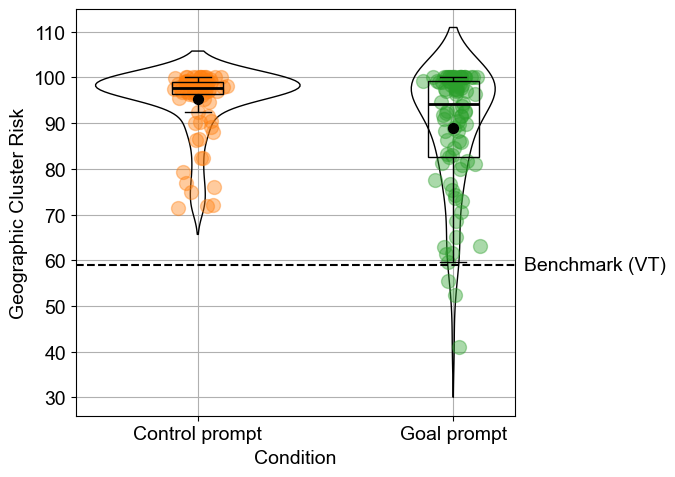

In [25]:
show_benchmark_violinplot(
    geo_us, 
    geo_benchmark_us, 
    'Benchmark (VT)', 
    'weight',
    'Geographic Cluster Risk', #US assets portfolio share [%]
    'cond',
    'study3_geoRisk'
)

                sum_sq     df         F   PR(>F)
label      1691.232670    1.0  14.63715  0.00018
Residual  20566.805721  178.0       NaN      NaN
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
    group1        group2   meandiff p-adj   lower   upper  reject
-----------------------------------------------------------------
Control prompt Goal prompt  -6.1305 0.0002 -9.2926 -2.9684   True
-----------------------------------------------------------------
group: ('Control prompt',) got t: 48.397809408877286 p_value: 0.0 dfs: 89 benchmark: 58.9625
group: ('Goal prompt',) got t: 21.230217566435968 p_value: 0.0 dfs: 89 benchmark: 58.9625


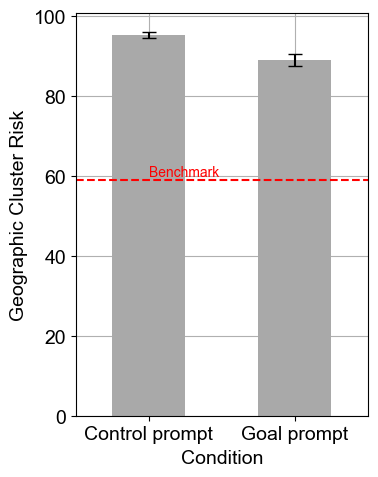

In [26]:
show_benchmark_errplot(geo_us, 
    geo_benchmark_us, 
    'Benchmark', 
    'weight',
    'Geographic Cluster Risk', #US assets portfolio share [%]
    'cond')

## Sector cluster risk

In [27]:
def prepare_sector_data(df, is_benchmark = False):
    if not is_benchmark:
        df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    df = df[df['sector'] != 'UNKNOWN'] 
    print(df.shape)
    return df

def calculate_concentration(result, group):
    result['weight_squared'] = result['weight'] ** 2
    result_sum = result.groupby(group)['weight'].sum().reset_index()
    result_sum = result_sum['weight'] ** 2
    result_grouped = result.groupby(group)['weight_squared'].sum().reset_index()
    result_grouped['concentration'] = result_grouped['weight_squared'] / result_sum
    return result_grouped

benchmark_filtered = prepare_sector_data(vt_dummy, True)
sec_benchmark = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
sec_benchmark = calculate_concentration(sec_benchmark, group_cols)
sec_benchmark = sec_benchmark.iloc[0]['concentration']

filtered_df = prepare_sector_data(ageRisk_resolved)
sec = filtered_df.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
#sec = prepare_dataframe(sec, 'weight', 'sector', sec['sector'].unique()) #left out as before
sec = calculate_concentration(sec, group_cols)

(9621, 15)
(481132, 35)


            sum_sq     df         F    PR(>F)
label     0.001352    1.0  0.045962  0.830491
Residual  5.237550  178.0       NaN       NaN
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
    group1        group2   meandiff p-adj  lower  upper  reject
---------------------------------------------------------------
Control prompt Goal prompt   0.0055 0.8305 -0.045 0.0559  False
---------------------------------------------------------------
group: ('Control prompt',) got t: 11.723389304483314 p_value: 0.0 dfs: 89 benchmark: 0.1528
group: ('Goal prompt',) got t: 9.099364060721017 p_value: 0.0 dfs: 89 benchmark: 0.1528
means:
cond
Control prompt    0.3331
Goal prompt       0.3386
Name: concentration, dtype: float64
stds:
cond
Control prompt    0.1460
Goal prompt       0.1938
Name: concentration, dtype: float64
cond
Control prompt    90
Goal prompt       90
Name: concentration, dtype: int64


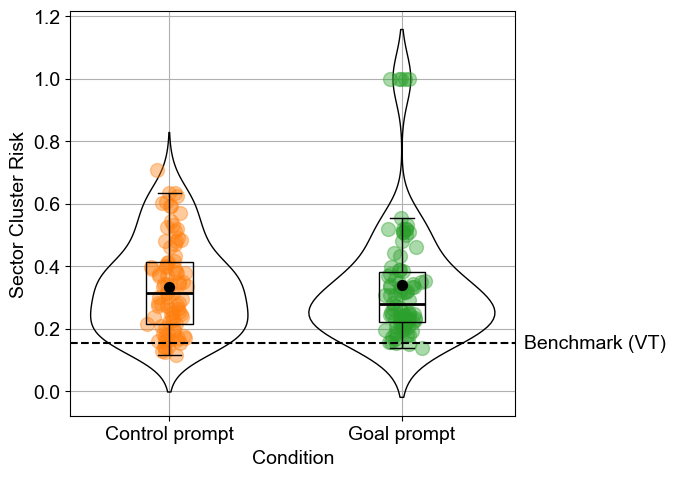

In [28]:
show_benchmark_violinplot(
    sec, 
    sec_benchmark, 
    'Benchmark (VT)', 
    'concentration',
    'Sector Cluster Risk', #Sector Concentration 
    'cond',
    'study3_sectorRisk'
)

            sum_sq     df         F    PR(>F)
label     0.001352    1.0  0.045962  0.830491
Residual  5.237550  178.0       NaN       NaN
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
    group1        group2   meandiff p-adj  lower  upper  reject
---------------------------------------------------------------
Control prompt Goal prompt   0.0055 0.8305 -0.045 0.0559  False
---------------------------------------------------------------
group: ('Control prompt',) got t: 11.723389304483314 p_value: 0.0 dfs: 89 benchmark: 0.1528
group: ('Goal prompt',) got t: 9.099364060721017 p_value: 0.0 dfs: 89 benchmark: 0.1528


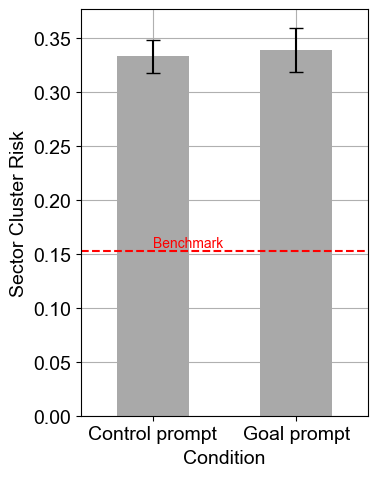

In [29]:
show_benchmark_errplot(
    sec, 
    sec_benchmark, 
    'Benchmark', 
    'concentration',
    'Sector Cluster Risk', #Sector Concentration 
    'cond')

## Concentration Map

In [30]:
def prepare_overview_data(df, isBenchmark = False):
    filtered_df = df.copy()
    if not isBenchmark:
        filtered_df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    filtered_df = filtered_df[filtered_df['country'] != 'UNKNOWN'] 
    filtered_df = filtered_df[filtered_df['sector'] != 'UNKNOWN']
    filtered_df['country'] = filtered_df['country'].apply(lambda x: 'US' if x == 'UNITED STATES' else 'Non-US')
    print(filtered_df.shape)
    return filtered_df

def calc_overview(raw, column, column_label, group1, group2=None):
    show_anova(raw, column, group1, group2)
    groups = [group1, group2] if group2 != None else [group1]    
    grouped = raw.groupby(groups)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    
    print(f'means:\n{round(means, 4)}')
    print(f'stds:\n{round(std_devs,4)}')
    print(sample_sizes)

def show_matched_ttest(raw, column, benchmark):
    for group_name, group_data in raw.groupby(column):
        group_values = group_data['weight']
        benchmark_val = 0
        if len(benchmark[benchmark[column] == group_name]) > 0:
            benchmark_val = benchmark[benchmark[column] == group_name].iloc[0]['weight']
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark_val)
        print(f'group: {group_name} with mean {round(group_values.mean(),4)} and std {round(group_values.std(),4)} got t: {round(t_statistic,2)} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark_val, 4)}')

filtered_df = prepare_overview_data(ageRisk_resolved)

sec_ov = filtered_df.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
sec_ov = fill_options(filtered_df, sec_ov, 'sector', group_cols)
calc_overview(sec_ov, 'weight','weight','sector')

bench_sec_ov = prepare_overview_data(vt_dummy, True).groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
show_matched_ttest(sec_ov, 'sector', bench_sec_ov)

geo_ov = filtered_df.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
gec_ov = fill_options(filtered_df, geo_ov, 'country', group_cols)
calc_overview(geo_ov, 'weight','weight','country')

bench_geo_ov = prepare_overview_data(vt_dummy, True).groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
show_matched_ttest(geo_ov, 'country', bench_geo_ov)


(474149, 35)
             sum_sq      df          F         PR(>F)
label     17.211725    13.0  109.07745  1.373028e-232
Residual  30.417753  2506.0        NaN            NaN
                                    Multiple Comparison of Means - Tukey HSD, FWER=0.05                                     
                  group1                                     group2                   meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------------------------------------------
           Academic & Educational Services                            Basic Materials   0.0143 0.9944 -0.0247  0.0533  False
           Academic & Educational Services                     Communication Services   0.0186 0.9451 -0.0203  0.0576  False
           Academic & Educational Services                          Consumer Cyclical   0.2164    0.0  0.1775  0.2554   True
           Academic & Educational Services                     Consumer Non

(9485, 15)


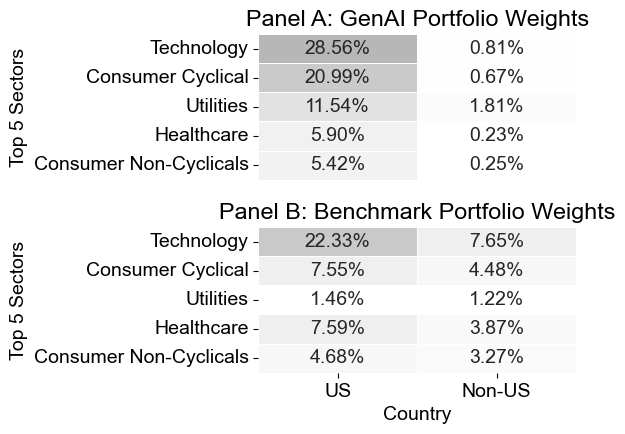

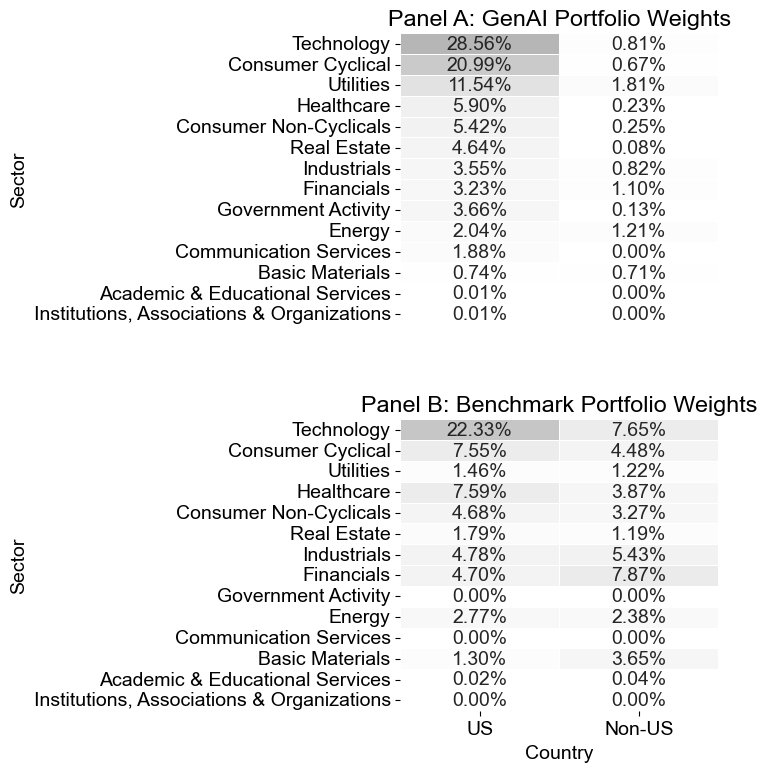

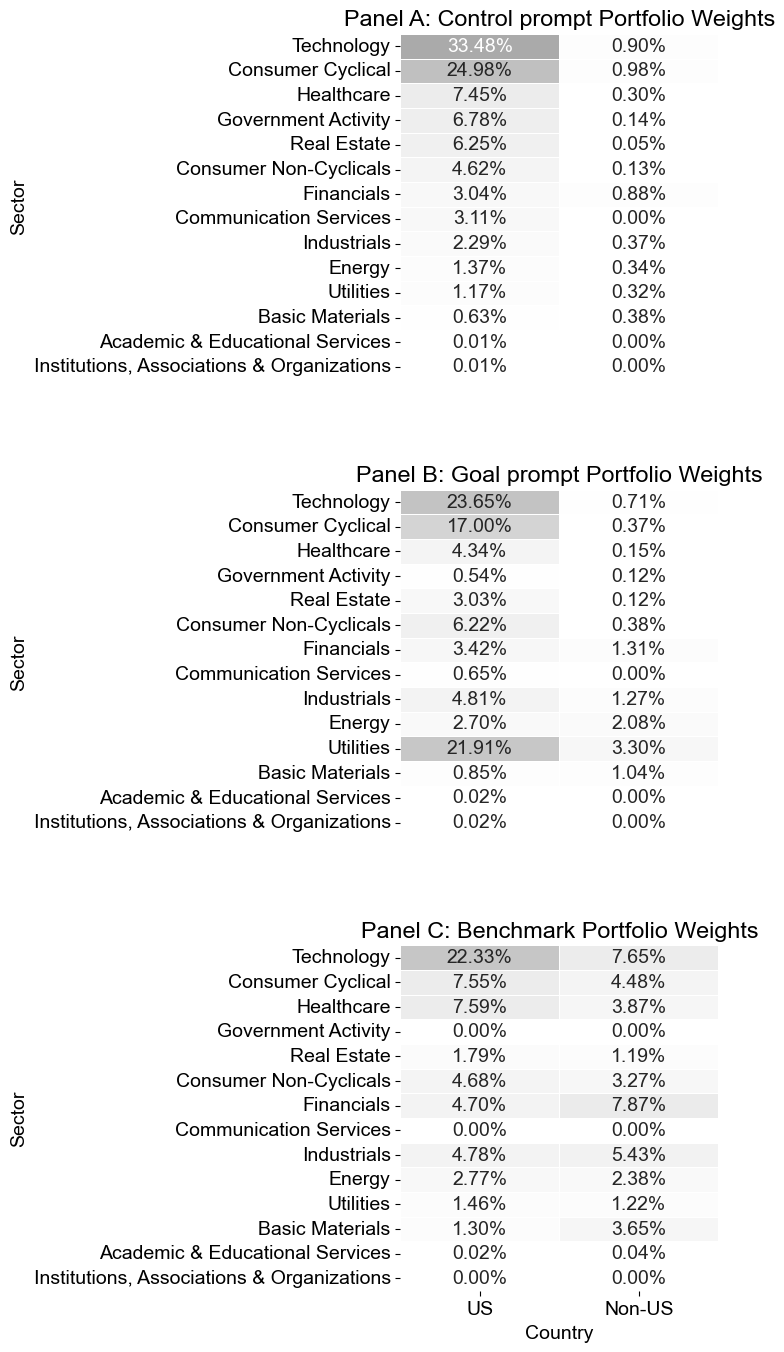

In [31]:
def fill_concentration(filtered_df, res, group_cols):
    sectors = filtered_df['sector'].unique()
    countries = filtered_df['country'].unique()
    group_cols_df = filtered_df[group_cols].drop_duplicates()
    all_combinations = pd.DataFrame(
        [row + [sector, country] for row in group_cols_df.values.tolist() for sector, country in itertools.product(sectors, countries)], 
        columns=group_cols+['sector', 'country'])

    merged_df = pd.merge(all_combinations, res, on=group_cols+['sector', 'country'], how='left')
    merged_df.fillna(0, inplace=True)
    return merged_df

def custom_heatmap(data, color_map="gray_r", annot=True, fmt=".2%", ax=None, max_color=None, **kwargs):
    sns.heatmap(data, cmap=color_map, annot=annot, fmt=fmt, linewidths=.5, cbar=False, ax=ax, vmax=max_color, **kwargs)

import numpy as np

def show_faceted_heatmap(combined_df, filename, show_top, width, height):
    all_sectors = combined_df['sector'].unique()

    g = sns.FacetGrid(combined_df, col="type", col_wrap=1, height=3, aspect=1.5, sharey=True)
    g.fig.set_size_inches(width, height)
    
    first_facet_data = combined_df[combined_df['type'] == combined_df['type'].unique()[0]]
    first_facet_pivot = first_facet_data.pivot_table(index='sector', columns='country', values='weight', fill_value=0)
    max_color_value = combined_df['weight'].max()

    if show_top:
        row_order = first_facet_pivot.sum(axis=1).sort_values(ascending=False).nlargest(5).index
    else:
        row_order = first_facet_pivot.sum(axis=1).sort_values(ascending=False).index

    for i, (ax, facet_name) in enumerate(zip(g.axes, combined_df['type'].unique())):
        ax.set_title(f'Panel {string.ascii_uppercase[i]}: {facet_name} Portfolio Weights')        
        facet_data = combined_df[combined_df['type'] == facet_name]
        facet_pivot = facet_data.pivot_table(index='sector', columns='country', values='weight', fill_value=0)
        facet_pivot = facet_pivot.sort_index(ascending=False)
        facet_pivot = facet_pivot.reindex(index=row_order, fill_value=0)
        facet_pivot = facet_pivot.reindex(columns=facet_pivot.columns[::-1], fill_value=0)  # Reverse column order
        custom_heatmap(facet_pivot, ax=ax, max_color=max_color_value)        
        ax.set_yticks(np.arange(len(facet_pivot.index)) + 0.5)
        ax.set_yticklabels(facet_pivot.index, va='center')  # Set y-tick labels
        if i == len(combined_df['type'].unique()) - 1:
            if ax.get_xticklabels():
                ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)

    y_label = 'Top 5 Sectors' if show_top else 'Sector'
    g.set_axis_labels("Country", y_label)
    plt.savefig(f'./figures/{filename}.png', bbox_inches='tight')

benchmark_filtered = prepare_overview_data(vt_dummy, True)
benchmark_concentration = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
benchmark_concentration = fill_concentration(benchmark_filtered, benchmark_concentration, group_cols)
benchmark_concentration['type'] = 'Benchmark'

concentration = filtered_df.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
concentration = fill_concentration(filtered_df, concentration, group_cols)
concentration_overview = concentration.copy()
concentration_overview['type'] = 'GenAI'
concentration_details = concentration.copy()
concentration_details['type'] = concentration_details['cond'] 

combined = pd.concat([concentration_overview, benchmark_concentration], ignore_index=True)

show_faceted_heatmap(combined, 'study3_overview_concentration_map', True, 4, 4)
show_faceted_heatmap(combined, 'study3_concentration_map', False, 4, 8)

combined_details = pd.concat([concentration_details, benchmark_concentration], ignore_index=True)

show_faceted_heatmap(combined_details, 'study3_concentration_map_details', False, 4, 14)

In [32]:
def show_faceted_heatmap(combined_df, filename, show_top, width, height):
    all_sectors = combined_df['sector'].unique()
    combined_df = combined_df.sort_values(by='type', ascending=False)
    replacements = {'Control prompt': 'Control Prompt', 'Goal prompt': 'Goal Prompt'}
    combined_df['type'] = combined_df['type'].replace(replacements)

    g = sns.FacetGrid(combined_df, col="type", col_wrap=1, height=3, aspect=1.5, sharey=True)
    g.fig.set_size_inches(width, height)
    
    first_facet_data = combined_df[combined_df['type'] == combined_df['type'].unique()[0]]
    first_facet_pivot = first_facet_data.pivot_table(index='country', columns='sector', values='weight', fill_value=0)
    max_color_value = combined_df['weight'].max()

    if show_top:
        column_order = first_facet_pivot.sum(axis=0).sort_values(ascending=False).nlargest(5).index
    else:
        column_order = first_facet_pivot.sum(axis=0).sort_values(ascending=False).index

    for i, (ax, facet_name) in enumerate(zip(g.axes, combined_df['type'].unique())):
        ax.set_title(f'Panel {string.ascii_uppercase[i]}: {facet_name} Portfolio Weights')        
        facet_data = combined_df[combined_df['type'] == facet_name]
        facet_pivot = facet_data.pivot_table(index='country', columns='sector', values='weight', fill_value=0)
        facet_pivot = facet_pivot.sort_index(ascending=False)
        facet_pivot = facet_pivot.reindex(columns=column_order, fill_value=0)
        custom_heatmap(facet_pivot, ax=ax, max_color=max_color_value)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right')
        if i == len(combined_df['type'].unique()) - 1:
            if ax.get_xticklabels():
                ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)

    x_label = 'Top 5 Sectors' if show_top else 'Sector'
    g.set_axis_labels(x_label, "Country")
    plt.savefig(f'./figures/{filename}.png', bbox_inches='tight')

(9485, 15)


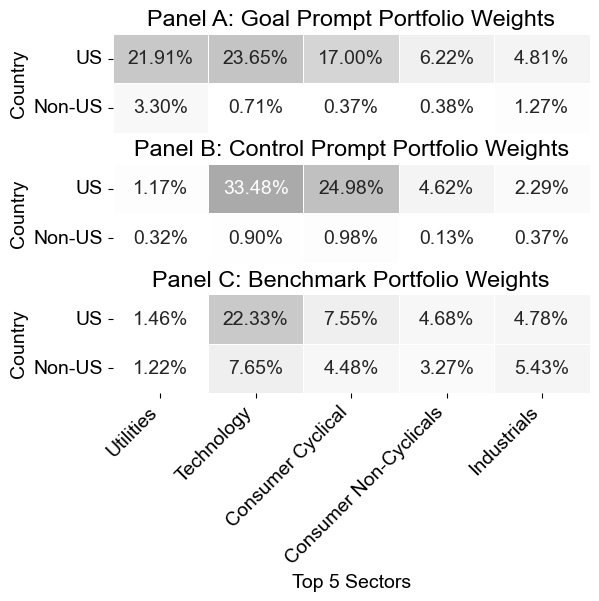

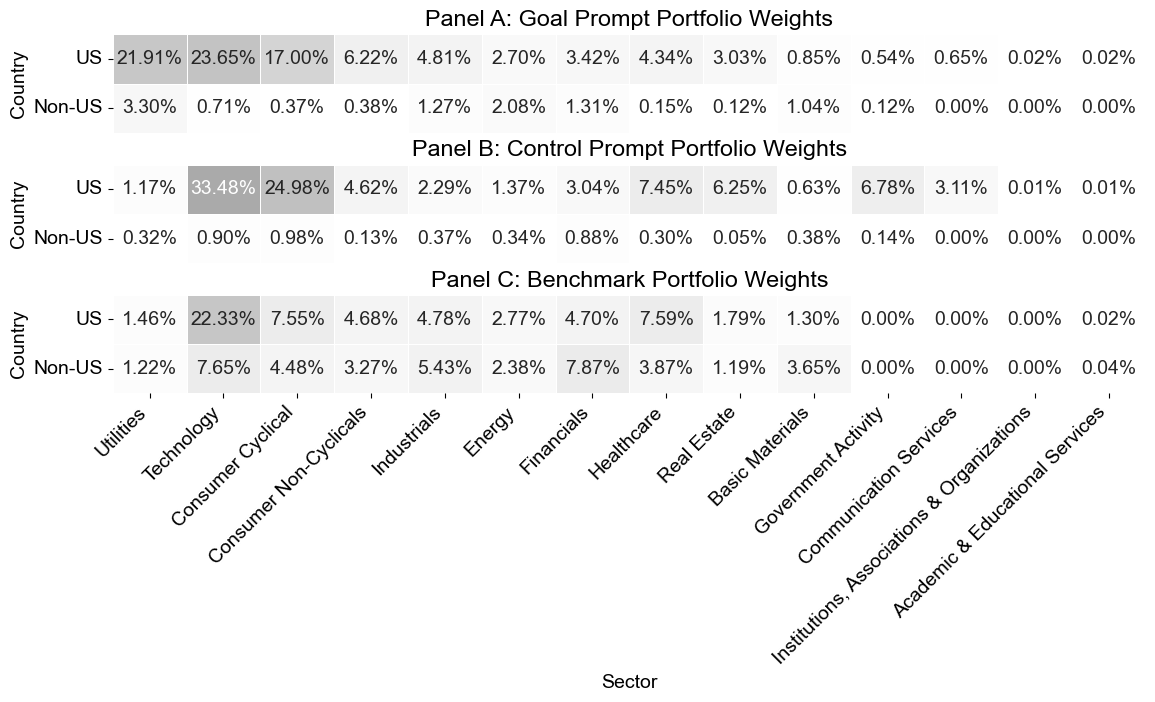

In [33]:
benchmark_filtered = prepare_overview_data(vt_dummy, True)
benchmark_concentration = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
benchmark_concentration = fill_concentration(benchmark_filtered, benchmark_concentration, group_cols)
benchmark_concentration['type'] = 'Benchmark'

concentration = filtered_df.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
concentration = fill_concentration(filtered_df, concentration, group_cols)
concentration_overview = concentration.copy()
concentration_overview['type'] = 'GenAI'
concentration_details = concentration.copy()
concentration_details['type'] = concentration_details['cond'] 

combined_details = pd.concat([concentration_details, benchmark_concentration], ignore_index=True)

show_faceted_heatmap(combined_details, 'study3_overview_concentration_map_horizontal', True, 6, 4)
show_faceted_heatmap(combined_details, 'study3_details_concentration_map_horizontal', False, 13, 4)

In [34]:
calc_overview(sec_ov, 'weight','weight','cond', 'sector')
show_matched_ttest(sec_ov[sec_ov['cond']=='Goal prompt'], 'sector', bench_sec_ov)

             sum_sq      df          F         PR(>F)
label     20.938025    27.0  72.401534  4.576008e-289
Residual  26.691453  2492.0        NaN            NaN
                                                      Multiple Comparison of Means - Tukey HSD, FWER=0.05                                                       
                           group1                                                       group2                            meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------------------------------------------------------------------------------
           (Control prompt, Academic & Educational Services)                            (Control prompt, Basic Materials)   0.0099    1.0 -0.0475  0.0673  False
           (Control prompt, Academic & Educational Services)                     (Control prompt, Communication Services)    0.031 0.9697 -0.0264  0.0884  False
           (Control prompt, Acade

## Active investment allocation risk

In [35]:
ter_data_study1 = pd.read_csv('../study1/etf_holdings/refinitiv/funds_ter_refinitiv.csv', index_col=0)
ter_data_study1 = ter_data_study1.iloc[1:].reset_index()
ter_data_study1.columns = ['fund', 'fund_type', 'ter', 'management_approach']
ter_data_study1 = ter_data_study1[~ter_data_study1['management_approach'].isna()]

ter_data_study2b = pd.read_csv('../study2b/data/refinitiv/funds_ter_refinitiv.csv', index_col=0)
ter_data_study2b = ter_data_study2b.iloc[1:].reset_index()
ter_data_study2b.columns = ['fund', 'fund_type', 'ter', 'management_approach']

ter_data_study2a = pd.read_csv('../study2a/data/refinitiv/ter_study2a.csv', index_col=0)
ter_data_study2a = ter_data_study2a.iloc[1:].reset_index()
ter_data_study2a.columns = ['fund', 'fund_type', 'ter', 'management_approach']

ter_data_study3 = pd.read_csv('./data/refinitiv/ter_study3.csv', index_col=0)
ter_data_study3 = ter_data_study3.iloc[1:].reset_index()
ter_data_study3.columns = ['fund', 'fund_type', 'ter', 'management_approach']

ter_data = pd.concat([ter_data_study1, ter_data_study2b, ter_data_study2a, ter_data_study3], ignore_index=True)
ter_data['fund'] = ter_data['fund'].str.split('.').str[0]
condition = ter_data['ter'].str.startswith('Unable to')
ter_data.loc[condition & ~ter_data['ter'].isna(), 'ter'] = np.nan

In [36]:
def set_management_approach(row):
    if row['asset_type'] in ['EQUITY', 
                               'CRYPTOCURRENCY', 
                               'BOND', 
                               'MONEYMARKET', 
                               'SEEDINVEST', 
                               'REALESTATE', 
                               'ROBO', 
                               'VENTURECAPITAL',
                               'PRIVATEEQUITY']:
        return 'Active'
    else:
        ticker = row['ticker_symbol']
        if ticker in ter_data['fund'].unique():
            approach = ter_data[ter_data['fund'] == ticker].iloc[0]['management_approach']
            return approach
        else:
            return 'UNKNOWN'

def calculate_approach_weight(group):
    summed = group.groupby('management_approach')['amount_to_invest'].sum().reset_index()
    total_amount = summed['amount_to_invest'].sum()
    summed['management_weight'] = summed['amount_to_invest'] / total_amount
    return summed

def get_management_data(df, groups):
    df = df[df['management_approach'] != 'UNKNOWN']
    management_data = df.groupby(groups).apply(calculate_approach_weight).reset_index()
    return management_data      

investment_ageRisk = ageRisk[~ageRisk['asset_type'].isin(['SAVING', 'DEPOSIT', 'IRA', 'ANNUITY'])]
investment_ageRisk = investment_ageRisk.copy()
investment_ageRisk['management_approach'] = investment_ageRisk.apply(set_management_approach, axis=1)
management_data = get_management_data(investment_ageRisk, group_cols)
management_data = prepare_dataframe(management_data, 'management_weight', 'management_approach', ['Active', 'Passive'])
management_data = management_data[management_data['management_approach'] == 'Active']
management_data['management_weight'] = management_data['management_weight'] *100

                 sum_sq     df          F        PR(>F)
label      38089.375644    1.0  61.946596  3.316434e-13
Residual  109447.642767  178.0        NaN           NaN
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
    group1        group2   meandiff p-adj  lower  upper  reject
---------------------------------------------------------------
Control prompt Goal prompt  29.0935   0.0 21.7989 36.388   True
---------------------------------------------------------------
group: ('Control prompt',) got t: 18.5083868852129 p_value: 0.0 dfs: 89 benchmark: 0
group: ('Goal prompt',) got t: 48.28580212392398 p_value: 0.0 dfs: 89 benchmark: 0
means:
cond
Control prompt    59.4121
Goal prompt       88.5056
Name: management_weight, dtype: float64
stds:
cond
Control prompt    30.4528
Goal prompt       17.3889
Name: management_weight, dtype: float64
cond
Control prompt    90
Goal prompt       90
Name: management_weight, dtype: int64


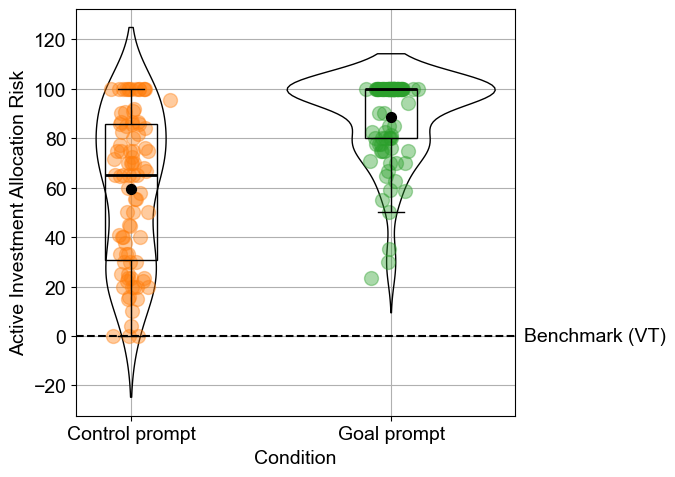

In [37]:
show_benchmark_violinplot(
    management_data, 
    0, 
    'Benchmark (VT)', 
    'management_weight',
    'Active Investment Allocation Risk', #Active management portfolio weight [%]
    'cond',
    'study3_activeRisk'
)

                 sum_sq     df          F        PR(>F)
label      38089.375644    1.0  61.946596  3.316434e-13
Residual  109447.642767  178.0        NaN           NaN
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
    group1        group2   meandiff p-adj  lower  upper  reject
---------------------------------------------------------------
Control prompt Goal prompt  29.0935   0.0 21.7989 36.388   True
---------------------------------------------------------------
group: ('Control prompt',) got t: 18.5083868852129 p_value: 0.0 dfs: 89 benchmark: 0
group: ('Goal prompt',) got t: 48.28580212392398 p_value: 0.0 dfs: 89 benchmark: 0


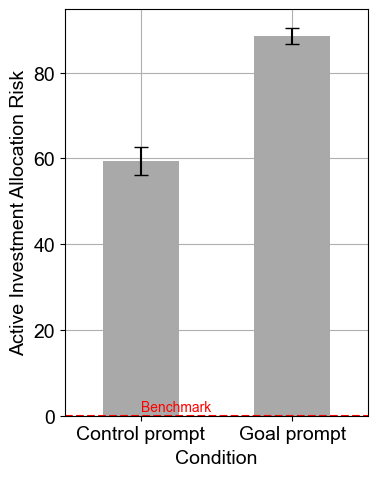

In [38]:
show_benchmark_errplot(
    management_data, 
    0, 
    'Benchmark', 
    'management_weight',
    'Active Investment Allocation Risk', #Active management portfolio weight [%]
    'cond')

## Total Expense Risk

In [39]:
fund_identifiers = ter_data['fund'].unique()
def assign_ter(row):
    ticker = row['ticker_symbol']
    if ticker in fund_identifiers:
        return ter_data[ter_data['fund'] == ticker].iloc[0]['ter']
    else: 
        return np.nan

def calculate_fund_weight(group, elem):
    summed = group.groupby(elem)['amount_to_invest'].sum().reset_index()
    total_amount = summed['amount_to_invest'].sum()
    summed['weight'] = summed['amount_to_invest'] / total_amount
    return summed

ter_benchmark = float(ter_data[ter_data['fund'] == 'VT'].iloc[0]['ter'])
ter_benchmark = ter_benchmark

filtered_df = ageRisk[ageRisk['asset_type'].isin(['ETF', 'MUTUALFUND'])]
ter_df = filtered_df.copy()
ter_df = ter_df.groupby(group_cols).apply(calculate_fund_weight, elem='ticker_symbol').reset_index()
ter_df['ter'] = ter_df.apply(assign_ter, axis=1)
ter_df['ter'] = ter_df['ter'].astype(float)
ter_df['ter_weight'] = ter_df['ter'] * ter_df['weight']
grouped_ter = ter_df.groupby(group_cols)['ter_weight'].sum().reset_index()

            sum_sq     df          F        PR(>F)
label     0.765509    1.0  27.316366  5.072520e-07
Residual  4.708005  168.0        NaN           NaN
     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
    group1        group2   meandiff p-adj lower  upper  reject
--------------------------------------------------------------
Control prompt Goal prompt   0.1344   0.0 0.0836 0.1851   True
--------------------------------------------------------------
group: ('Control prompt',) got t: 5.228165969045312 p_value: 0.0 dfs: 80 benchmark: 0.07
group: ('Goal prompt',) got t: 17.321003811135537 p_value: 0.0 dfs: 88 benchmark: 0.07
means:
cond
Control prompt    0.1843
Goal prompt       0.3186
Name: ter_weight, dtype: float64
stds:
cond
Control prompt    0.1967
Goal prompt       0.1354
Name: ter_weight, dtype: float64
cond
Control prompt    81
Goal prompt       89
Name: ter_weight, dtype: int64


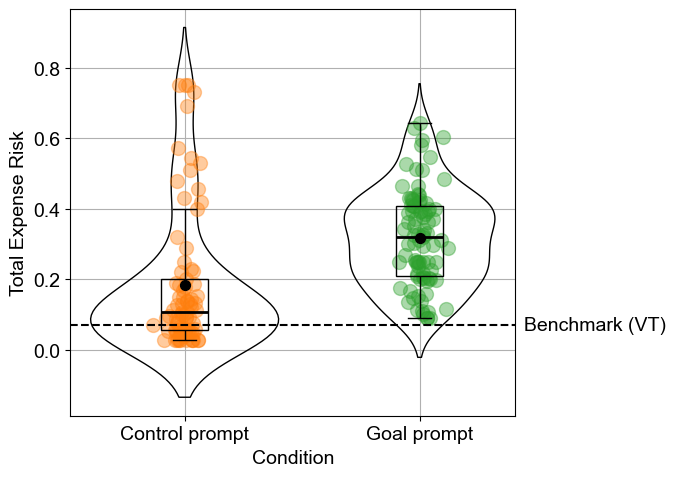

In [40]:
show_benchmark_violinplot(
    grouped_ter, 
    ter_benchmark, 
    'Benchmark (VT)', 
    'ter_weight',
    'Total Expense Risk', #TER % 
    'cond',
    'study3_terRisk'
)

In [41]:
# Control for different N (portfolios being excluded due to no investment in ETFs or mutual funds
ter_control = grouped_ter[grouped_ter['cond'] == 'Control prompt']['ter_weight']
ter_goal = grouped_ter[grouped_ter['cond'] == 'Goal prompt']['ter_weight']

stat, p = stats.mannwhitneyu(ter_control, ter_goal)
print(f'control-goal: {stat}, {p}')

# Perform one-sample Wilcoxon signed-rank test
stat_bench, p_bench = stats.wilcoxon(ter_control - ter_benchmark)
print(f'control-benchmark: {stat_bench}, {p_bench}')

stat_goal_bench, p_goal_bench = stats.wilcoxon(ter_goal - ter_benchmark)
print(f'goal-benchmark: {stat_goal_bench}, {p_goal_bench}')

# Perform Chi-Square test
count_control = [90-ter_control.size, ter_control.size]
count_goal = [90-ter_goal.size, ter_goal.size]

chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_control, count_goal])
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')

control-goal: 1562.5, 1.8852983533980991e-10
control-benchmark: 615.0, 1.4222826215616325e-06
goal-benchmark: 0.0, 2.534666499693836e-16
chi-square: 5.188235294117648, 0.02274029611529969, df:1


            sum_sq     df          F        PR(>F)
label     0.765509    1.0  27.316366  5.072520e-07
Residual  4.708005  168.0        NaN           NaN
     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
    group1        group2   meandiff p-adj lower  upper  reject
--------------------------------------------------------------
Control prompt Goal prompt   0.1344   0.0 0.0836 0.1851   True
--------------------------------------------------------------
group: ('Control prompt',) got t: 5.228165969045312 p_value: 0.0 dfs: 80 benchmark: 0.07
group: ('Goal prompt',) got t: 17.321003811135537 p_value: 0.0 dfs: 88 benchmark: 0.07


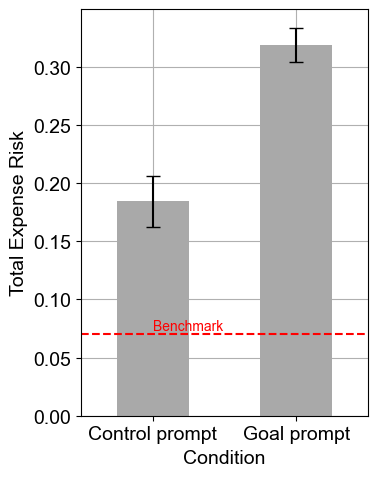

In [42]:
show_benchmark_errplot(
    grouped_ter, 
    ter_benchmark, 
    'Benchmark', 
    'ter_weight',
    'Total Expense Risk', #TER % 
    'cond')

## Trend chasing risk

In [43]:
vt_prepared = benchmark_vt
vt_prepared['symbol'] = vt_prepared['symbol'].str.split('.').str[0]
vt_prepared = vt_prepared['symbol'].unique()

volume_dict = {}
start_date = "2023-04-01"
end_date = "2023-06-30"

In [44]:
json_file_path = '../study1/benchmark/vt_benchmark_holdings_volume_202304_3m.json'

# Open and read the JSON file
with open(json_file_path, 'r') as json_file:
    # Load the JSON data into a dictionary
    volume_dict = json.load(json_file)
    
most_active_stocks = sorted(volume_dict.items(), key=lambda x: x[1], reverse=True)

# Most traded in the last 3 months by volume
most_traded = []
for i, (symbol, volume) in enumerate(most_active_stocks[:20], 1):
    most_traded.append(symbol)
    print(f"{i}. Symbol: {symbol}, Total Volume: {volume}")

1. Symbol: TSLA, Total Volume: 8627649000
2. Symbol: PLTR, Total Volume: 4490639300
3. Symbol: AMD, Total Volume: 4201460900
4. Symbol: AMZN, Total Volume: 3899624000
5. Symbol: F, Total Volume: 3708650700
6. Symbol: AAPL, Total Volume: 3541966300
7. Symbol: NIO, Total Volume: 3235177200
8. Symbol: SOFI, Total Volume: 3204363300
9. Symbol: BAC, Total Volume: 3044131000
10. Symbol: NKLA, Total Volume: 3010655200
11. Symbol: NVDA, Total Volume: 2965437300
12. Symbol: INTC, Total Volume: 2762170900
13. Symbol: CCL, Total Volume: 2498772900
14. Symbol: T, Total Volume: 2442695800
15. Symbol: GOOGL, Total Volume: 2081408400
16. Symbol: LCID, Total Volume: 1905241200
17. Symbol: AI, Total Volume: 1890107300
18. Symbol: NU, Total Volume: 1711794600
19. Symbol: MSFT, Total Volume: 1699893000
20. Symbol: PACW, Total Volume: 1662858500


In [45]:
def getTop(conds, cond, equities_cond, equities_grouped):
    top_data = {}
    
    for co in conds:
        top_equities_total = equities_cond[equities_cond['cond'] == co]['amount_to_invest']
        top_total = cond[cond['cond'] == co]['amount_to_invest']
        top_cond = equities_grouped[equities_grouped['cond'] == co]
        top_cond['pct_of_equities'] = top_cond['amount_to_invest'].apply(lambda x: x / top_equities_total)
        top_cond['pct_of_total'] = top_cond['amount_to_invest'].apply(lambda x : x / top_total)
        top_cond = top_cond.sort_values(by='amount_to_invest', ascending=False)
        top_data[co] = top_cond
        
    return top_data

def showTop(conds, top_data):
    top_dict = {}
    for co in conds:
        top = top_data[co]
        top_equities_sum = top['pct_of_equities'].sum()
        top_total_sum = top['pct_of_total'].sum()
        print(f'{co} top: % of equities: {top_equities_sum} and % of total {top_total_sum}')

        top3 = top.head(3)
        top3 = top3[top3['ticker_symbol'].isin(most_traded)]
        top3_equities_sum = top3['pct_of_equities'].sum()
        top3_total_sum = top3['pct_of_total'].sum()
        print(f'{co} top 3: % of equities: {top3_equities_sum} and % of total {top3_total_sum}')
        print(f'{top3}\n')
        top_dict[co] = top3['ticker_symbol'].tolist()
    return top_dict

conds = ageRisk['cond'].unique()
ageRisk_cond = ageRisk.groupby(['cond'])['amount_to_invest'].sum().reset_index()
ageRisk_equities = ageRisk[ageRisk['asset_type'] == 'EQUITY']
ageRisk_equities_cond = ageRisk_equities.groupby(['cond'])['amount_to_invest'].sum().reset_index()
ageRisk_equities_grouped = ageRisk_equities.groupby(['cond','ticker_symbol'])['amount_to_invest'].sum().reset_index()

top_data = getTop(conds, ageRisk_cond, ageRisk_equities_cond, ageRisk_equities_grouped)
top_dict = showTop(conds, top_data)

Control prompt top: % of equities: 0.9999999999999999 and % of total 0.42698998418555617
Control prompt top 3: % of equities: 0.645679012345679 and % of total 0.275698471270427
              cond ticker_symbol  amount_to_invest  pct_of_equities  \
0   Control prompt          AAPL           99000.0         0.244444   
22  Control prompt          TSLA           92500.0         0.228395   
3   Control prompt          AMZN           70000.0         0.172840   

    pct_of_total  
0       0.104375  
22      0.097522  
3       0.073801  

Goal prompt top: % of equities: 1.0 and % of total 0.3272425249169435
Goal prompt top 3: % of equities: 0.233502538071066 and % of total 0.07641196013289037
           cond ticker_symbol  amount_to_invest  pct_of_equities  pct_of_total
51  Goal prompt          TSLA           69000.0         0.233503      0.076412



/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_26115/3554050832.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_cond['pct_of_equities'] = top_cond['amount_to_invest'].apply(lambda x: x / top_equities_total)
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_26115/3554050832.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_cond['pct_of_total'] = top_cond['amount_to_invest'].apply(lambda x : x / top_total)
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_26115/3554

In [46]:
top3_benchmark = vt_dummy.sort_values(by='weight', ascending=False).head(3) 
top3_benchmark #all included in top 20 most traded

,fund,code,equity,symbol,#shares,weight,country,type,sector,amount,cond,ai,age,risk-taking,iteration
93854,VT,LP40120747,APPLE INC ORD,AAPL,8132495.0,0.038911,UNITED STATES,Ordinary Shares,Technology,389.11,VT,VT,1,low,0
93855,VT,NaN,MICROSOFT CORP ORD,MSFT,4055679.0,0.033854,UNITED STATES,Ordinary Shares,Technology,338.54,VT,VT,1,low,0
93856,VT,NaN,AMAZON.COM INC ORD,AMZN,4909845.0,0.017257,UNITED STATES,Ordinary Shares,Consumer Cyclical,172.57,VT,VT,1,low,0


In [47]:
def calcTopMeans(df, top_dict):
    top_df = None

    for cond, top_assets in top_dict.items():
        filtered_df = df[(df['cond'] == cond) & (df['ticker_symbol'].isin(top_assets))]
        top_df = pd.concat([top_df, filtered_df])
    
    top_df = prepare_dataframe(top_df, 'weight')    
    result = top_df.groupby(['cond', 'age', 'risk-taking', 'iteration'])['weight'].sum().reset_index()
    return result
 
benchmark_trends = top3_benchmark.groupby('cond')['weight'].sum().reset_index().iloc[0]['weight']
trends_data = calcTopMeans(ageRisk_resolved, top_dict)

trends_data['weight'] = trends_data['weight'] *100
benchmark_trends = benchmark_trends * 100

                sum_sq     df         F        PR(>F)
label     16783.575179    1.0  54.54996  5.634624e-12
Residual  54765.876249  178.0       NaN           NaN
       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2   meandiff p-adj  lower    upper   reject
------------------------------------------------------------------
Control prompt Goal prompt -19.3124   0.0 -24.4724 -14.1524   True
------------------------------------------------------------------
group: ('Control prompt',) got t: 7.579171175305345 p_value: 0.0 dfs: 89 benchmark: 9.0022
group: ('Goal prompt',) got t: -1.2328919192445587 p_value: 0.2209 dfs: 89 benchmark: 9.0022
means:
cond
Control prompt    26.9462
Goal prompt        7.6338
Name: weight, dtype: float64
stds:
cond
Control prompt    22.4604
Goal prompt       10.5298
Name: weight, dtype: float64
cond
Control prompt    90
Goal prompt       90
Name: weight, dtype: int64


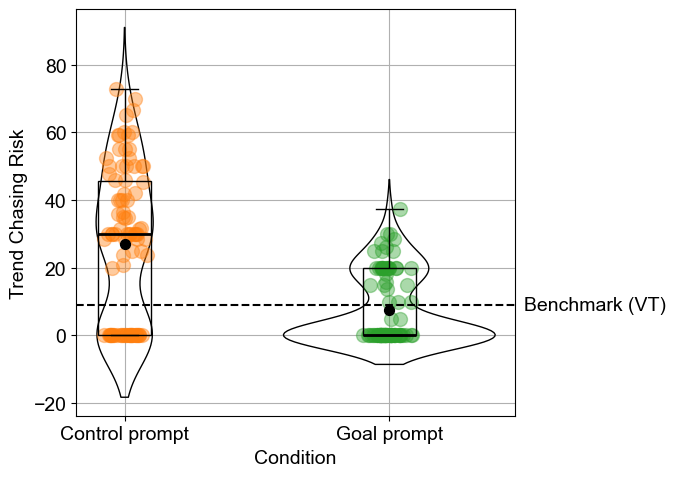

In [48]:
show_benchmark_violinplot(
    trends_data, 
    benchmark_trends, 
    'Benchmark (VT)', 
    'weight',
    'Trend Chasing Risk', #Top 3 trending equities portfolio share [%]
    'cond',
    'study3_trendRisk'
)

                sum_sq     df         F        PR(>F)
label     16783.575179    1.0  54.54996  5.634624e-12
Residual  54765.876249  178.0       NaN           NaN
       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2   meandiff p-adj  lower    upper   reject
------------------------------------------------------------------
Control prompt Goal prompt -19.3124   0.0 -24.4724 -14.1524   True
------------------------------------------------------------------
group: ('Control prompt',) got t: 7.579171175305345 p_value: 0.0 dfs: 89 benchmark: 9.0022
group: ('Goal prompt',) got t: -1.2328919192445587 p_value: 0.2209 dfs: 89 benchmark: 9.0022


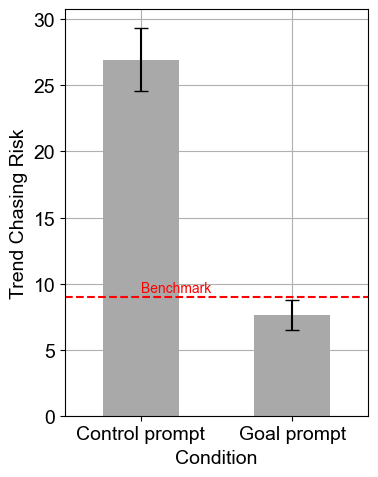

In [49]:
show_benchmark_errplot(
    trends_data, 
    benchmark_trends, 
    'Benchmark', 
    'weight',
    'Trend Chasing Risk', #Top 3 trending equities portfolio share [%]
    'cond')

## Goal attainment (ESG Score)

In [50]:
esg_equities = pd.read_csv('./data/refinitiv/esg_equities_refinitiv.csv', index_col=0)
esg_equities = esg_equities.iloc[1:].reset_index()
esg_equities.columns = ['fund', 'fund_tick', 'esg_score', 'governance_score', 'social_score', 'environmental_score']
esg_equities = esg_equities[['fund', 'esg_score']]

esg_etfs = pd.read_csv('./data/refinitiv/esg_etfs_refinitiv.csv', index_col=0)
esg_etfs = esg_etfs.iloc[1:].reset_index()
esg_etfs.columns = ['fund', 'fund_tick', 'esg_score_auto', 'esg_score']
esg_etfs = esg_etfs[['fund', 'esg_score']]

esg_funds = pd.read_csv('./data/refinitiv/esg_funds_refinitiv.csv', index_col=0)
esg_funds = esg_funds.iloc[1:].reset_index()
esg_funds.columns = ['fund', 'fund_tick', 'esg_score_auto', 'esg_score']
esg_funds = esg_funds[['fund', 'esg_score']]

esg_data = pd.concat([esg_equities, esg_etfs, esg_funds], ignore_index=True)
esg_data['fund'] = esg_data['fund'].str.split('.').str[0]
condition = ter_data['ter'].str.startswith('NULL')
esg_data = esg_data.dropna(subset=['fund'])
esg_data.loc[condition & ~esg_data['esg_score'].isna(), 'esg_score'] = np.nan

In [51]:
esg_identifiers = esg_data['fund'].unique()
def assign_esg_data(row):
    ticker = row['ticker_symbol']
    if ticker in esg_identifiers:
        esg_val = esg_data[esg_data['fund'] == ticker].iloc[0]['esg_score']
        return float(esg_val)
    else: 
        return np.nan

esg_benchmark = float(esg_data[esg_data['fund'] == 'VT'].iloc[0]['esg_score'])

filtered_df = ageRisk[ageRisk['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
filtered_df = filtered_df.copy()
filtered_df['esg'] = filtered_df.apply(assign_esg_data, axis=1)
filtered_df = filtered_df[~filtered_df['esg'].isnull()] # need to exclude rows where we do not have ESG data
filtered_df['esg'] = filtered_df['esg'].astype(float)
esg_df = filtered_df.copy()
esg_df = esg_df.groupby(group_cols).apply(calculate_fund_weight, elem=['ticker_symbol', 'esg']).reset_index()
esg_df['esg_weight'] = esg_df['esg'] * esg_df['weight']
esg_df.head(20)
grouped_esg = esg_df.groupby(group_cols)['esg_weight'].sum().reset_index()

               sum_sq     df         F    PR(>F)
label        0.016121    1.0  0.000523  0.981778
Residual  5485.284513  178.0       NaN       NaN
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
    group1        group2   meandiff p-adj   lower  upper reject
---------------------------------------------------------------
Control prompt Goal prompt   0.0189 0.9818 -1.6141 1.652  False
---------------------------------------------------------------
group: ('Control prompt',) got t: 0.6709952194784007 p_value: 0.504 dfs: 89 benchmark: 71.12
group: ('Goal prompt',) got t: 1.0830413825227458 p_value: 0.2817 dfs: 89 benchmark: 71.12
means:
cond
Control prompt    71.5867
Goal prompt       71.6056
Name: esg_weight, dtype: float64
stds:
cond
Control prompt    6.5983
Goal prompt       4.2538
Name: esg_weight, dtype: float64
cond
Control prompt    90
Goal prompt       90
Name: esg_weight, dtype: int64


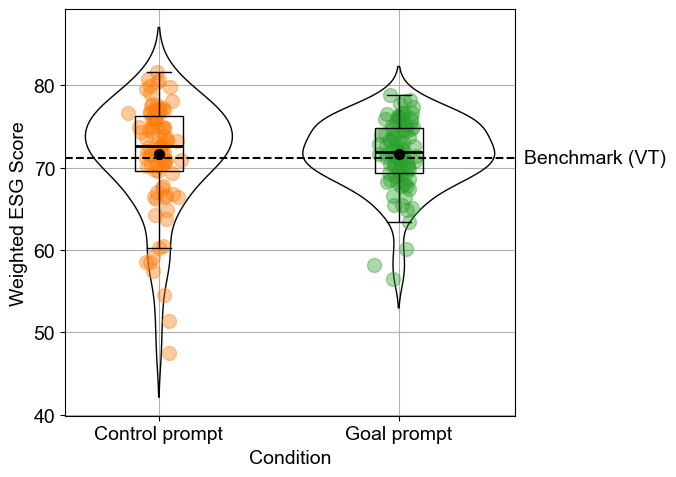

In [52]:
show_benchmark_violinplot(
    grouped_esg, 
    esg_benchmark, 
    'Benchmark (VT)', 
    'esg_weight',
    'Weighted ESG Score', #Top 3 trending equities portfolio share [%]
    'cond',
    'study3_esg'
)

In [53]:
k = len(esg_df['cond'].unique())
N = len(esg_df)
df1 = k - 1
df2 = N - k
print(f"df1: {df1}, df2: {df2}")

df1: 1, df2: 693


In [54]:
esg_control = esg_df[esg_df['cond'] == 'Control prompt']['esg_weight']
esg_goal = esg_df[esg_df['cond'] == 'Goal prompt']['esg_weight']

statistic, p_value = stats.levene(esg_control, esg_goal)

print(f"Statistic: {statistic}, p-value: {p_value}")

Statistic: 23.834037760905883, p-value: 1.3045551662459682e-06


               sum_sq     df         F    PR(>F)
label        0.016121    1.0  0.000523  0.981778
Residual  5485.284513  178.0       NaN       NaN
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
    group1        group2   meandiff p-adj   lower  upper reject
---------------------------------------------------------------
Control prompt Goal prompt   0.0189 0.9818 -1.6141 1.652  False
---------------------------------------------------------------
group: ('Control prompt',) got t: 0.6709952194784007 p_value: 0.504 dfs: 89 benchmark: 71.12
group: ('Goal prompt',) got t: 1.0830413825227458 p_value: 0.2817 dfs: 89 benchmark: 71.12


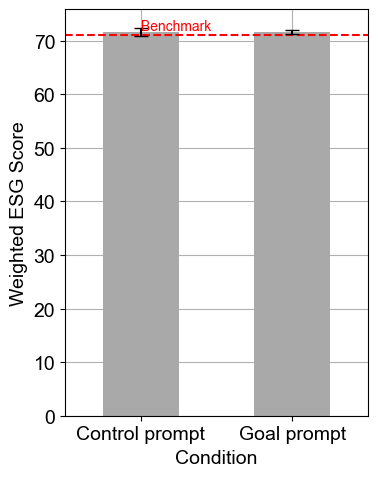

In [55]:
show_benchmark_errplot(
    grouped_esg, 
    esg_benchmark, 
    'Benchmark', 
    'esg_weight',
    'Weighted ESG Score', 
    'cond')